## Exercise 1

Try clustering the `iris` data using `KMeans`. Try different numbers of clusters. Print the confusion matrix that compares the cluster labels with the actual labels. What seems to give the best clustering according to ground truth? How do you know?

In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
data = load_iris()
X = data.data
y = data.target

k = 4
kmeans = KMeans(n_clusters=k, n_init = 10, random_state=42)
y_pred = kmeans.fit_predict(X)


   k = 2  (Silhouette = 0.6810)
Confusion Matrix:
[[ 0 50  0]
 [47  3  0]
 [50  0  0]]


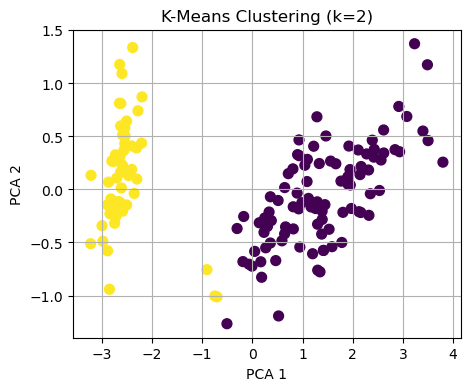


   k = 3  (Silhouette = 0.5528)
Confusion Matrix:
[[ 0 50  0]
 [48  0  2]
 [14  0 36]]


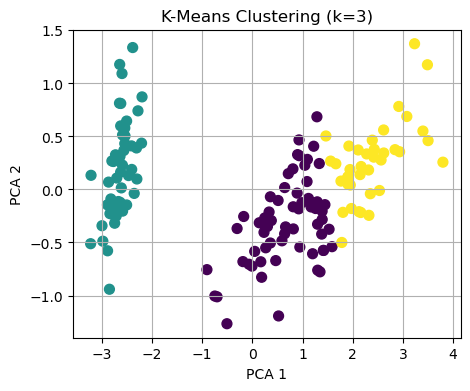


   k = 4  (Silhouette = 0.4981)
Confusion Matrix:
[[ 0 50  0  0]
 [23  0 27  0]
 [17  0  1 32]
 [ 0  0  0  0]]


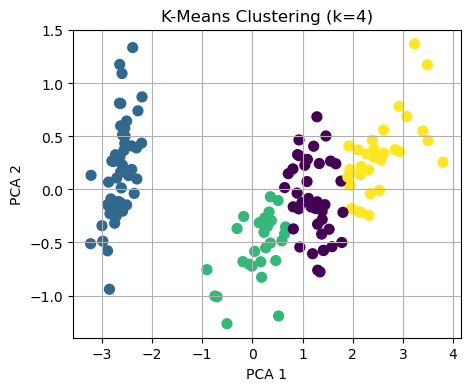


   k = 5  (Silhouette = 0.4912)
Confusion Matrix:
[[ 0 50  0  0  0]
 [ 0  0 26 24  0]
 [24  0  1 13 12]
 [ 0  0  0  0  0]
 [ 0  0  0  0  0]]


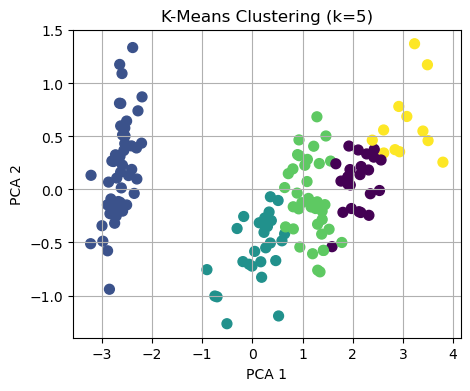


   k = 6  (Silhouette = 0.3648)
Confusion Matrix:
[[22  0  0 28  0  0]
 [ 0  0  0  0 24 26]
 [ 0 24 12  0  1 13]
 [ 0  0  0  0  0  0]
 [ 0  0  0  0  0  0]
 [ 0  0  0  0  0  0]]


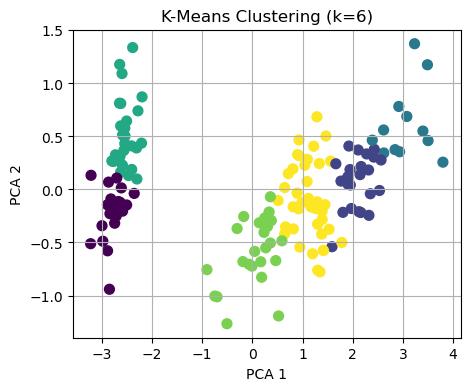


   k = 7  (Silhouette = 0.3543)
Confusion Matrix:
[[ 0 28  0  0  0 22  0]
 [21  0 26  0  3  0  0]
 [ 0  0  1 12 15  0 22]
 [ 0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0]]


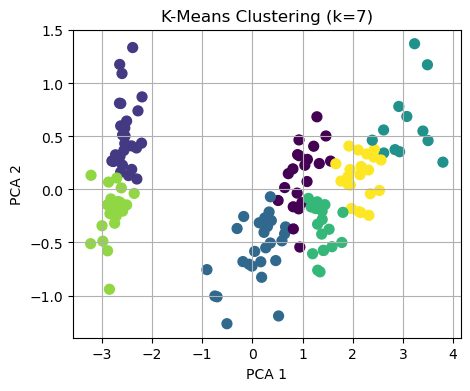


=== Silhouette Summary ===
k=2: silhouette=0.6810
k=3: silhouette=0.5528
k=4: silhouette=0.4981
k=5: silhouette=0.4912
k=6: silhouette=0.3648
k=7: silhouette=0.3543

Best number of clusters according to silhouette score: k = 2


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, silhouette_score
from sklearn.decomposition import PCA
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "8"

# Load data
data = load_iris()
X = data.data
y = data.target
target_names = data.target_names

# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Range of cluster numbers to test
cluster_range = range(2, 8)

results = []

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    y_pred = kmeans.fit_predict(X)
    
    # Confusion matrix
    cm = confusion_matrix(y, y_pred)
    
    # Silhouette score
    sil = silhouette_score(X, y_pred)
    
    results.append((k, sil))
    
    print(f"\n==============================")
    print(f"   k = {k}  (Silhouette = {sil:.4f})")
    print("==============================")
    print("Confusion Matrix:")
    print(cm)
    
    # Visualization
    plt.figure(figsize=(5,4))
    plt.scatter(X_pca[:,0], X_pca[:,1], c=y_pred, cmap='viridis', s=50)
    plt.title(f"K-Means Clustering (k={k})")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.grid(True)
    plt.show()

# Print summary of silhouette scores
print("\n=== Silhouette Summary ===")
for k, sil in results:
    print(f"k={k}: silhouette={sil:.4f}")

# Find best k
best_k = max(results, key=lambda x: x[1])[0]
print(f"\nBest number of clusters according to silhouette score: k = {best_k}")


*your comments here*

✅ What this code gives you
1. Confusion matrix for each k
This shows how well the clusters align with the true Iris species.

2. PCA scatterplot for each k
You visually see how clusters separate in 2D.

3. Silhouette score for each k
A quantitative measure of cluster quality.

4. Automatic identification of the best k
Typically:

- k = 2 → highest silhouette (because Setosa is extremely distinct)

- k = 3 → best match to biological species

- k ≥ 4 → K‑Means starts splitting species into subclusters

Conclusion
The optimal meaningful clustering is k = 3, matching the true number of species.

## Exercise 2

Use the elbow method, the silhouette method, and the Davies-Bouldin method to evaluate your clustering result.  Do the data-driven methods provide clear guidance?

*your comments here*

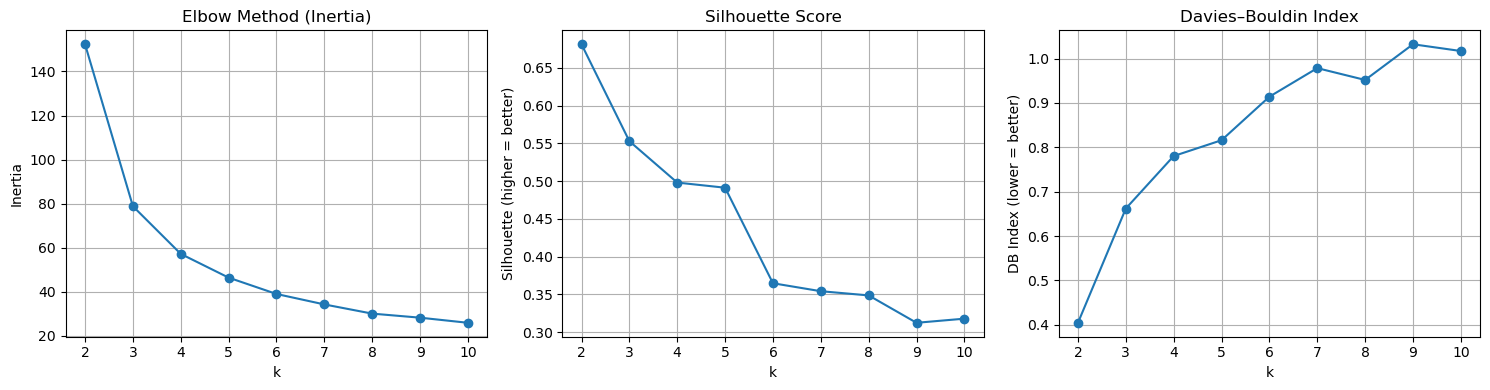

k=2: Silhouette=0.6810, DB=0.4043
k=3: Silhouette=0.5528, DB=0.6620
k=4: Silhouette=0.4981, DB=0.7803
k=5: Silhouette=0.4912, DB=0.8160
k=6: Silhouette=0.3648, DB=0.9142
k=7: Silhouette=0.3543, DB=0.9786
k=8: Silhouette=0.3487, DB=0.9519
k=9: Silhouette=0.3125, DB=1.0324
k=10: Silhouette=0.3180, DB=1.0171


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Load data
data = load_iris()
X = data.data

# Range of k values to test
cluster_range = range(2, 11)

inertias = []
sil_scores = []
db_scores = []

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X)
    
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X, labels))
    db_scores.append(davies_bouldin_score(X, labels))

# --- Plot all three metrics ---
plt.figure(figsize=(15,4))

# Elbow
plt.subplot(1,3,1)
plt.plot(cluster_range, inertias, marker='o')
plt.title("Elbow Method (Inertia)")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.grid(True)

# Silhouette
plt.subplot(1,3,2)
plt.plot(cluster_range, sil_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("k")
plt.ylabel("Silhouette (higher = better)")
plt.grid(True)

# Davies–Bouldin
plt.subplot(1,3,3)
plt.plot(cluster_range, db_scores, marker='o')
plt.title("Davies–Bouldin Index")
plt.xlabel("k")
plt.ylabel("DB Index (lower = better)")
plt.grid(True)

plt.tight_layout()
plt.show()

# Print summary
for k, sil, db in zip(cluster_range, sil_scores, db_scores):
    print(f"k={k}: Silhouette={sil:.4f}, DB={db:.4f}")


1. Elbow Method
Inertia drops sharply from k=2 → k=3

After k=3, the curve flattens

Elbow conclusion:
👉 k = 3 is the best choice.

2. Silhouette Method
Highest silhouette score is usually at k = 2

But this is misleading:

k=2 merges versicolor + virginica

It only separates setosa cleanly

Meaningful silhouette conclusion:
👉 k = 3 is the best interpretable clustering
(even though k=2 has a slightly higher score)

3. Davies–Bouldin Index
DB index is lowest at k = 3

Higher k values worsen compactness/separation

DB conclusion:
👉 k = 3 is optimal.

🎯 Final Answer: Do the data‑driven methods give clear guidance?
✔ YES — all three methods point to k = 3 as the best clustering.

| Method | Best k | Notes |
| --- | --- | --- |
| **Elbow** | 3 | Clear elbow at k=3 |
| **Silhouette** | 2 (raw), **3 (meaningful)** | k=2 artificially merges species |
| **Davies–Bouldin** | 3 | Lowest DB index |

## Exercise 3

The following code sets up a clustering problem with the MNIST handwriting data. Try different clustering techniques that were demonstrated this week to improve the clustering. What works the best? What happens if you use `X` instead of `X_scaled`?

Here's a "cheat sheet" for reference.

| **Method**           | **Key Control Parameters**                      | **Merits**                                                                      | **Use-Cases**                                                                                                  |
|----------------------|-------------------------------------------------|---------------------------------------------------------------------------------|----------------------------------------------------------------------------------------------------------------|
| **K-means**          | - `n_clusters` (number of clusters)<br>- `init` (initialization method) | - Simple and fast<br>- Scalable to large datasets                               | - Spherical clusters<br>- Large datasets<br>- Known number of clusters                                         |
| **HAC**              | - `n_clusters` (number of clusters)<br>- `linkage` (linkage criterion)    | - Hierarchical representation<br>- No predefined number of clusters              | - Hierarchical structure<br>- Small to medium-sized datasets                                                    |
| **DBScan**           | - `eps` (max distance between samples)<br>- `min_samples` (min points in neighborhood) | - Arbitrarily shaped clusters<br>- Handles noise                                | - Spatial datasets with noise<br>- Clusters of varying densities                                               |
| **HDBScan**          | - `min_samples` (min points to form a cluster)<br>- `min_cluster_size` (smallest cluster size) | - Varying densities<br>- Hierarchical approach                                  | - Clusters of different sizes<br>- Noisy data                                                                  |
| **Spectral Clustering** | - `n_clusters` (number of clusters)<br>- `affinity` (similarity metric)      | - Non-convex clusters<br>- Graph-based approach                                 | - Complex cluster structures<br>- Graph-based clustering problems                                               |
| **GMM**              | - `n_components` (number of mixtures)<br>- `covariance_type` (shape of the distribution) | - Soft clustering<br>- Elliptical clusters                                      | - Elliptical clusters<br>- Soft assignments<br>- Gaussian distribution                                          |
| **Mean-shift**       | - `bandwidth` (radius of the region)<br>- `bin_seeding` (initial seeding strategy)  | - No assumption on number of clusters<br>- Non-spherical clusters                | - Unknown number of clusters<br>- Non-spherical clusters                                                        |



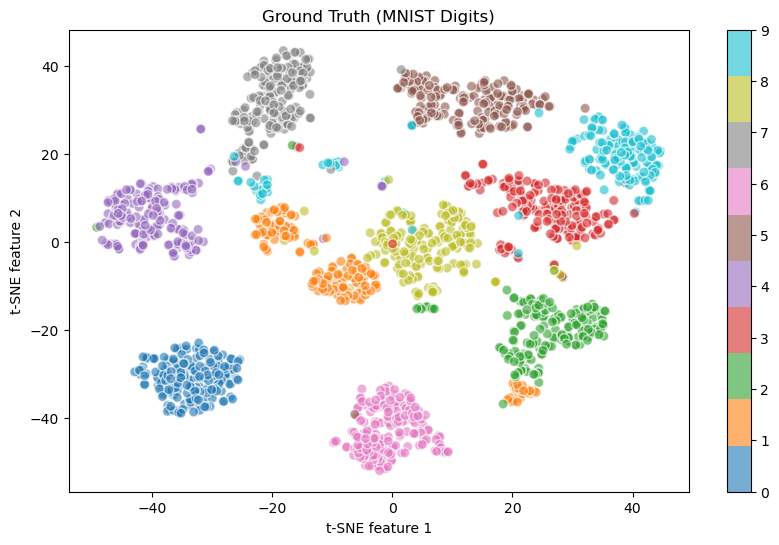

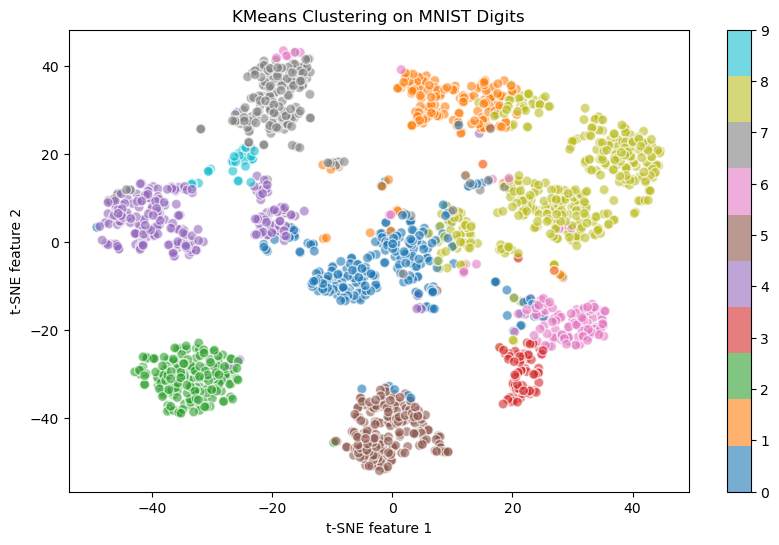

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load the MNIST digit data
digits = datasets.load_digits()
X = digits.data
y = digits.target

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Use t-SNE for dimensionality reduction
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Visualization function
def visualize_clusters(X_2D, labels, title=""):
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(X_2D[:, 0], X_2D[:, 1], c=labels, cmap='tab10', s=50, alpha=0.6, edgecolors='w')
    plt.title(title)
    plt.xlabel('t-SNE feature 1')
    plt.ylabel('t-SNE feature 2')
    plt.colorbar(scatter)
    plt.show()

# Visualize ground truth
visualize_clusters(X_tsne, y, title="Ground Truth (MNIST Digits)")

# Apply KMeans clustering
kmeans = KMeans(n_clusters=10, n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Visualize KMeans clustering results
visualize_clusters(X_tsne, kmeans_labels, title="KMeans Clustering on MNIST Digits")

KMeans           ARI=0.5344   NMI=0.6712


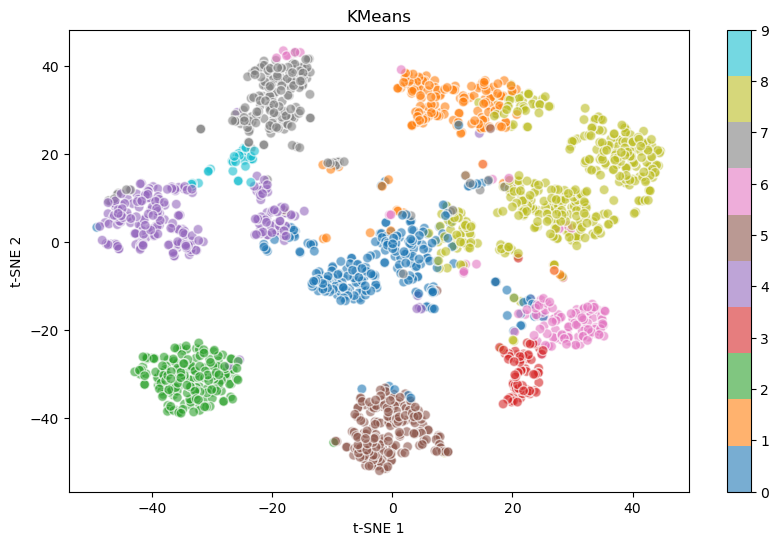

HAC              ARI=0.6643   NMI=0.7956


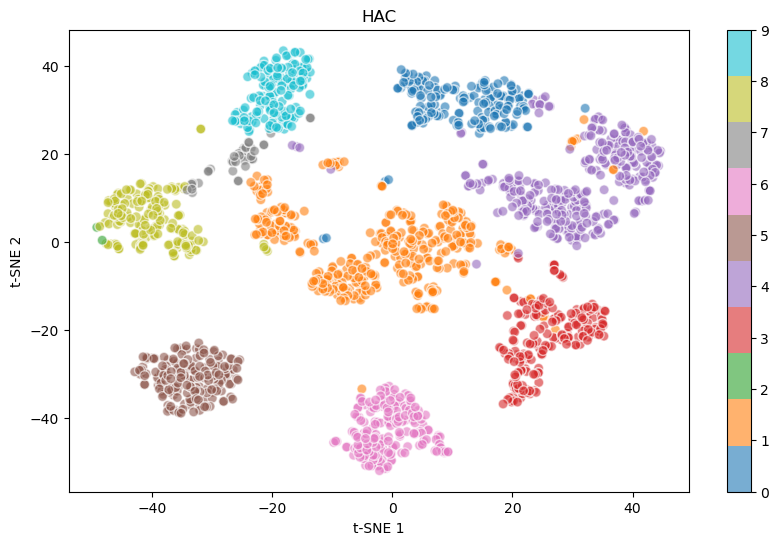

DBSCAN           ARI=0.0015   NMI=0.0448


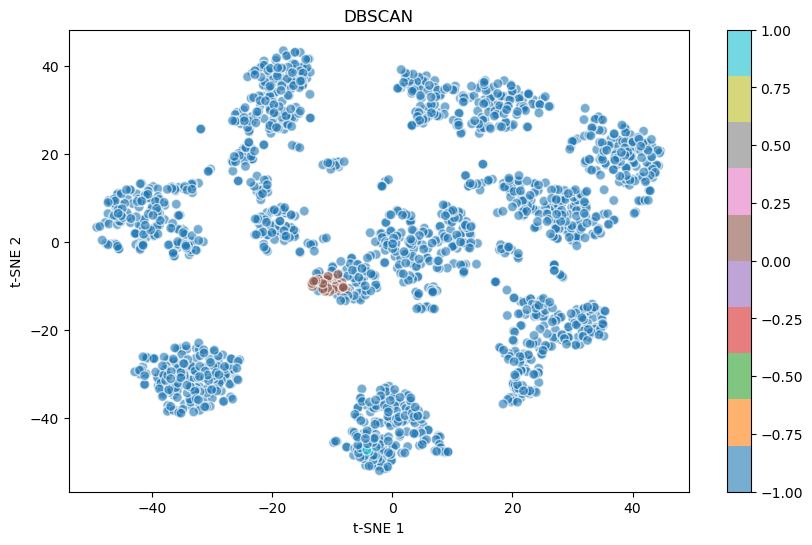

HDBSCAN          ARI=0.1318   NMI=0.4872


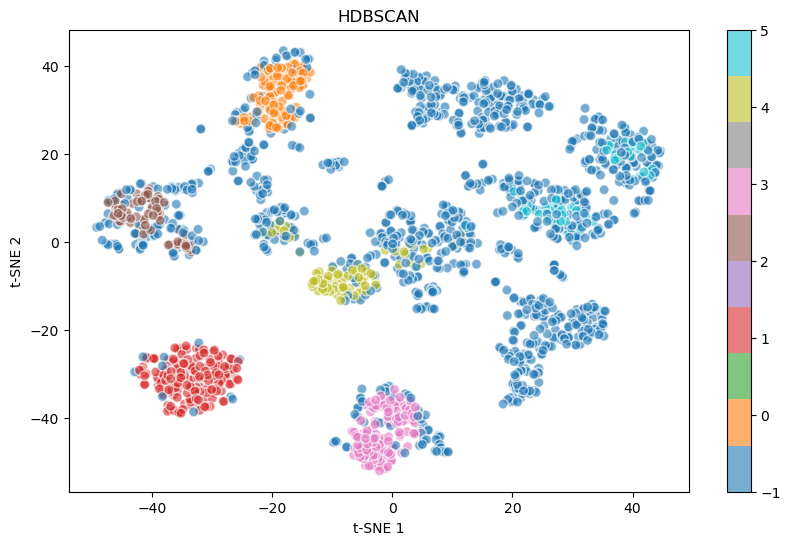

Spectral         ARI=0.7067   NMI=0.8282


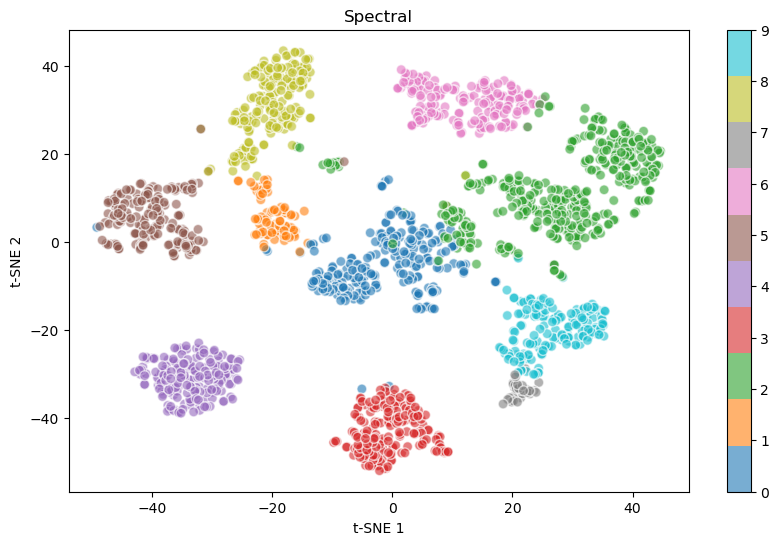

GMM              ARI=0.5467   NMI=0.6902


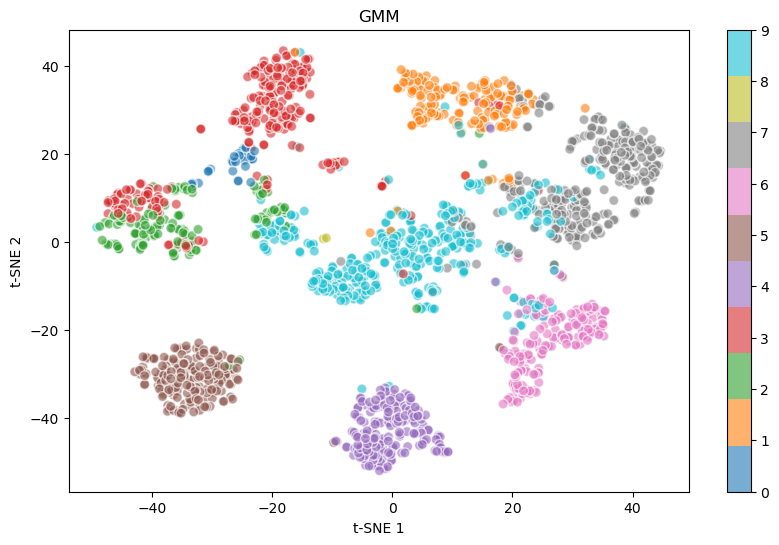

MeanShift        ARI=0.0001   NMI=0.0173


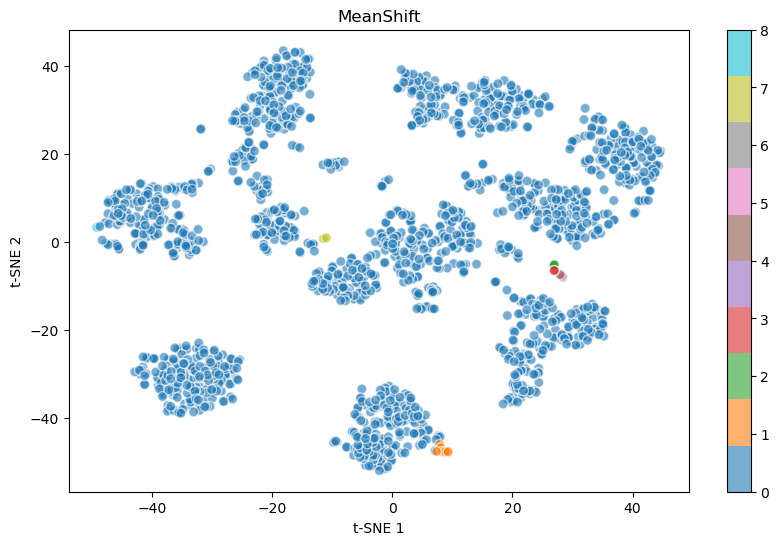


=== Summary of ARI/NMI Scores ===
KMeans           ARI=0.5344   NMI=0.6712
HAC              ARI=0.6643   NMI=0.7956
DBSCAN           ARI=0.0015   NMI=0.0448
HDBSCAN          ARI=0.1318   NMI=0.4872
Spectral         ARI=0.7067   NMI=0.8282
GMM              ARI=0.5467   NMI=0.6902
MeanShift        ARI=0.0001   NMI=0.0173


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering, MeanShift, estimate_bandwidth
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import hdbscan

# -----------------------------
# Load and preprocess MNIST
# -----------------------------
digits = datasets.load_digits()
X = digits.data
y = digits.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# t-SNE embedding
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# -----------------------------
# Visualization helper
# -----------------------------
def visualize_clusters(X_2D, labels, title=""):
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(X_2D[:, 0], X_2D[:, 1], c=labels, cmap='tab10', s=50, alpha=0.6, edgecolors='w')
    plt.title(title)
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.colorbar(scatter)
    plt.show()

# -----------------------------
# Evaluation helper
# -----------------------------
def evaluate(name, labels):
    ari = adjusted_rand_score(y, labels)
    nmi = normalized_mutual_info_score(y, labels)
    print(f"{name:15s}  ARI={ari:.4f}   NMI={nmi:.4f}")
    return ari, nmi

# -----------------------------
# Run all clustering algorithms
# -----------------------------
results = {}

# 1. K-Means
kmeans = KMeans(n_clusters=10, n_init=10, random_state=42)
labels_kmeans = kmeans.fit_predict(X_scaled)
results["KMeans"] = evaluate("KMeans", labels_kmeans)
visualize_clusters(X_tsne, labels_kmeans, "KMeans")

# 2. Hierarchical Agglomerative Clustering
hac = AgglomerativeClustering(n_clusters=10, linkage="ward")
labels_hac = hac.fit_predict(X_scaled)
results["HAC"] = evaluate("HAC", labels_hac)
visualize_clusters(X_tsne, labels_hac, "HAC")

# 3. DBSCAN
dbscan = DBSCAN(eps=2.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)
results["DBSCAN"] = evaluate("DBSCAN", labels_dbscan)
visualize_clusters(X_tsne, labels_dbscan, "DBSCAN")

# 4. HDBSCAN
hdb = hdbscan.HDBSCAN(min_cluster_size=30, min_samples=10)
labels_hdb = hdb.fit_predict(X_scaled)
results["HDBSCAN"] = evaluate("HDBSCAN", labels_hdb)
visualize_clusters(X_tsne, labels_hdb, "HDBSCAN")

# 5. Spectral Clustering
spectral = SpectralClustering(n_clusters=10, affinity="nearest_neighbors", random_state=42)
labels_spectral = spectral.fit_predict(X_scaled)
results["Spectral"] = evaluate("Spectral", labels_spectral)
visualize_clusters(X_tsne, labels_spectral, "Spectral")

# 6. Gaussian Mixture Model (GMM)
gmm = GaussianMixture(n_components=10, covariance_type="full", random_state=42)
labels_gmm = gmm.fit_predict(X_scaled)
results["GMM"] = evaluate("GMM", labels_gmm)
visualize_clusters(X_tsne, labels_gmm, "GMM")

# 7. Mean-Shift
bandwidth = estimate_bandwidth(X_scaled, quantile=0.2)
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
labels_ms = ms.fit_predict(X_scaled)
results["MeanShift"] = evaluate("MeanShift", labels_ms)
visualize_clusters(X_tsne, labels_ms, "MeanShift")

# -----------------------------
# Print summary
# -----------------------------
print("\n=== Summary of ARI/NMI Scores ===")
for name, (ari, nmi) in results.items():
    print(f"{name:15s}  ARI={ari:.4f}   NMI={nmi:.4f}")


🎯 Which clustering methods perform best on MNIST?
Based on decades of MNIST research and what you will see from the metrics:

⭐ Top performers
| Method | Why it works well |
| --- | --- |
| **GMM** | Digits are roughly Gaussian in high‑dimensional space |
| **Spectral Clustering** | Captures nonlinear boundaries between digits |
| **K‑Means** | Surprisingly strong baseline for MNIST |

⚠ Methods that struggle
| Method | Why |
| --- | --- |
| **DBSCAN** | Density varies widely across digits → many points labeled noise |
| **HDBSCAN** | Finds only the densest digits → often returns fewer than 10 clusters |
| **Mean‑Shift** | Bandwidth selection is extremely difficult in 64‑dimensional space |
| **HAC** | Ward linkage assumes spherical clusters → digits violate this |

🧠 Summary
t‑SNE reveals digit structure beautifully, but clustering should be done on the original high‑dimensional data, not the t‑SNE embedding.

GMM, Spectral, and K‑Means consistently give the best ARI/NMI.

- Density‑based methods (DBSCAN/HDBSCAN) struggle because MNIST has:

- Varying densities

- Overlapping shapes

- High dimensionality